In [ ]:
import sys

from synthetic_anomalies import (
    add_event_group,
    reverse_event,
    add_jump,
    simple_noise_event,  # simple replaces a section with random noise.
    add_seasonal_cycle_increase,
    add_trend_increase,
)

import pathlib

import matplotlib.pyplot as plt

import sys

sys.path.append("../")
from forecasting_analysis.utils.data_parsing_tools import load_all_locations

# Synthetic anomalies types for early warning testing. 

These are preliminary results for the early warning system evaluation.


So far the following anomalies are available:
- Trend increase ✔
- Var increase ✔
- Event Anomaly ✔
- Sudden deformation ✔
- Noise anomaly ✔

All anomalies are added to an original ps-time series and their intensity can be adjusted. Further, they can be stacked.




In [43]:
# Load a PS time series: 

start = 100
data_source_path = pathlib.Path() / "../raw_data/Datenpaket_BBD"
data, meta = load_all_locations(data_source_path)
data = data["Lister"]["asc0"]
data = data[["720593"]]

In [ ]:
a = add_trend_increase(
    data,
    increase_start_index=start,
    increase_strength=5,
    nonlinear_trend=True,
    nl_trend_strength=2,
).interpolate()

b = add_seasonal_cycle_increase(
    data, increase_start_index=start, increase_strength=0.1
).interpolate()

c = add_trend_increase(
    add_seasonal_cycle_increase(
        data, increase_start_index=start, increase_strength=0.1
    ).interpolate(),
    increase_start_index=start,
    increase_strength=5,
    nonlinear_trend=True,
    nl_trend_strength=2,
).interpolate()

d = add_event_group(
    data,
    reverse_event(data, 100, increase_start_index=start),
    increase_start_index=start,
).interpolate()
e = add_jump(data, increase_start_index=start, increase_strength=10).interpolate()

f = add_jump(
    add_trend_increase(
        data,
        increase_start_index=start,
        increase_strength=2,
        nonlinear_trend=True,
        nl_trend_strength=2,
    ).interpolate(),
    increase_start_index=start,
    increase_strength=10,
).interpolate()

/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:175: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = scipy.optimize.curve_fit(sinfunc, tt, yy, p0=guess)
/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:175: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = scipy.optimize.curve_fit(sinfunc, tt, yy, p0=guess)


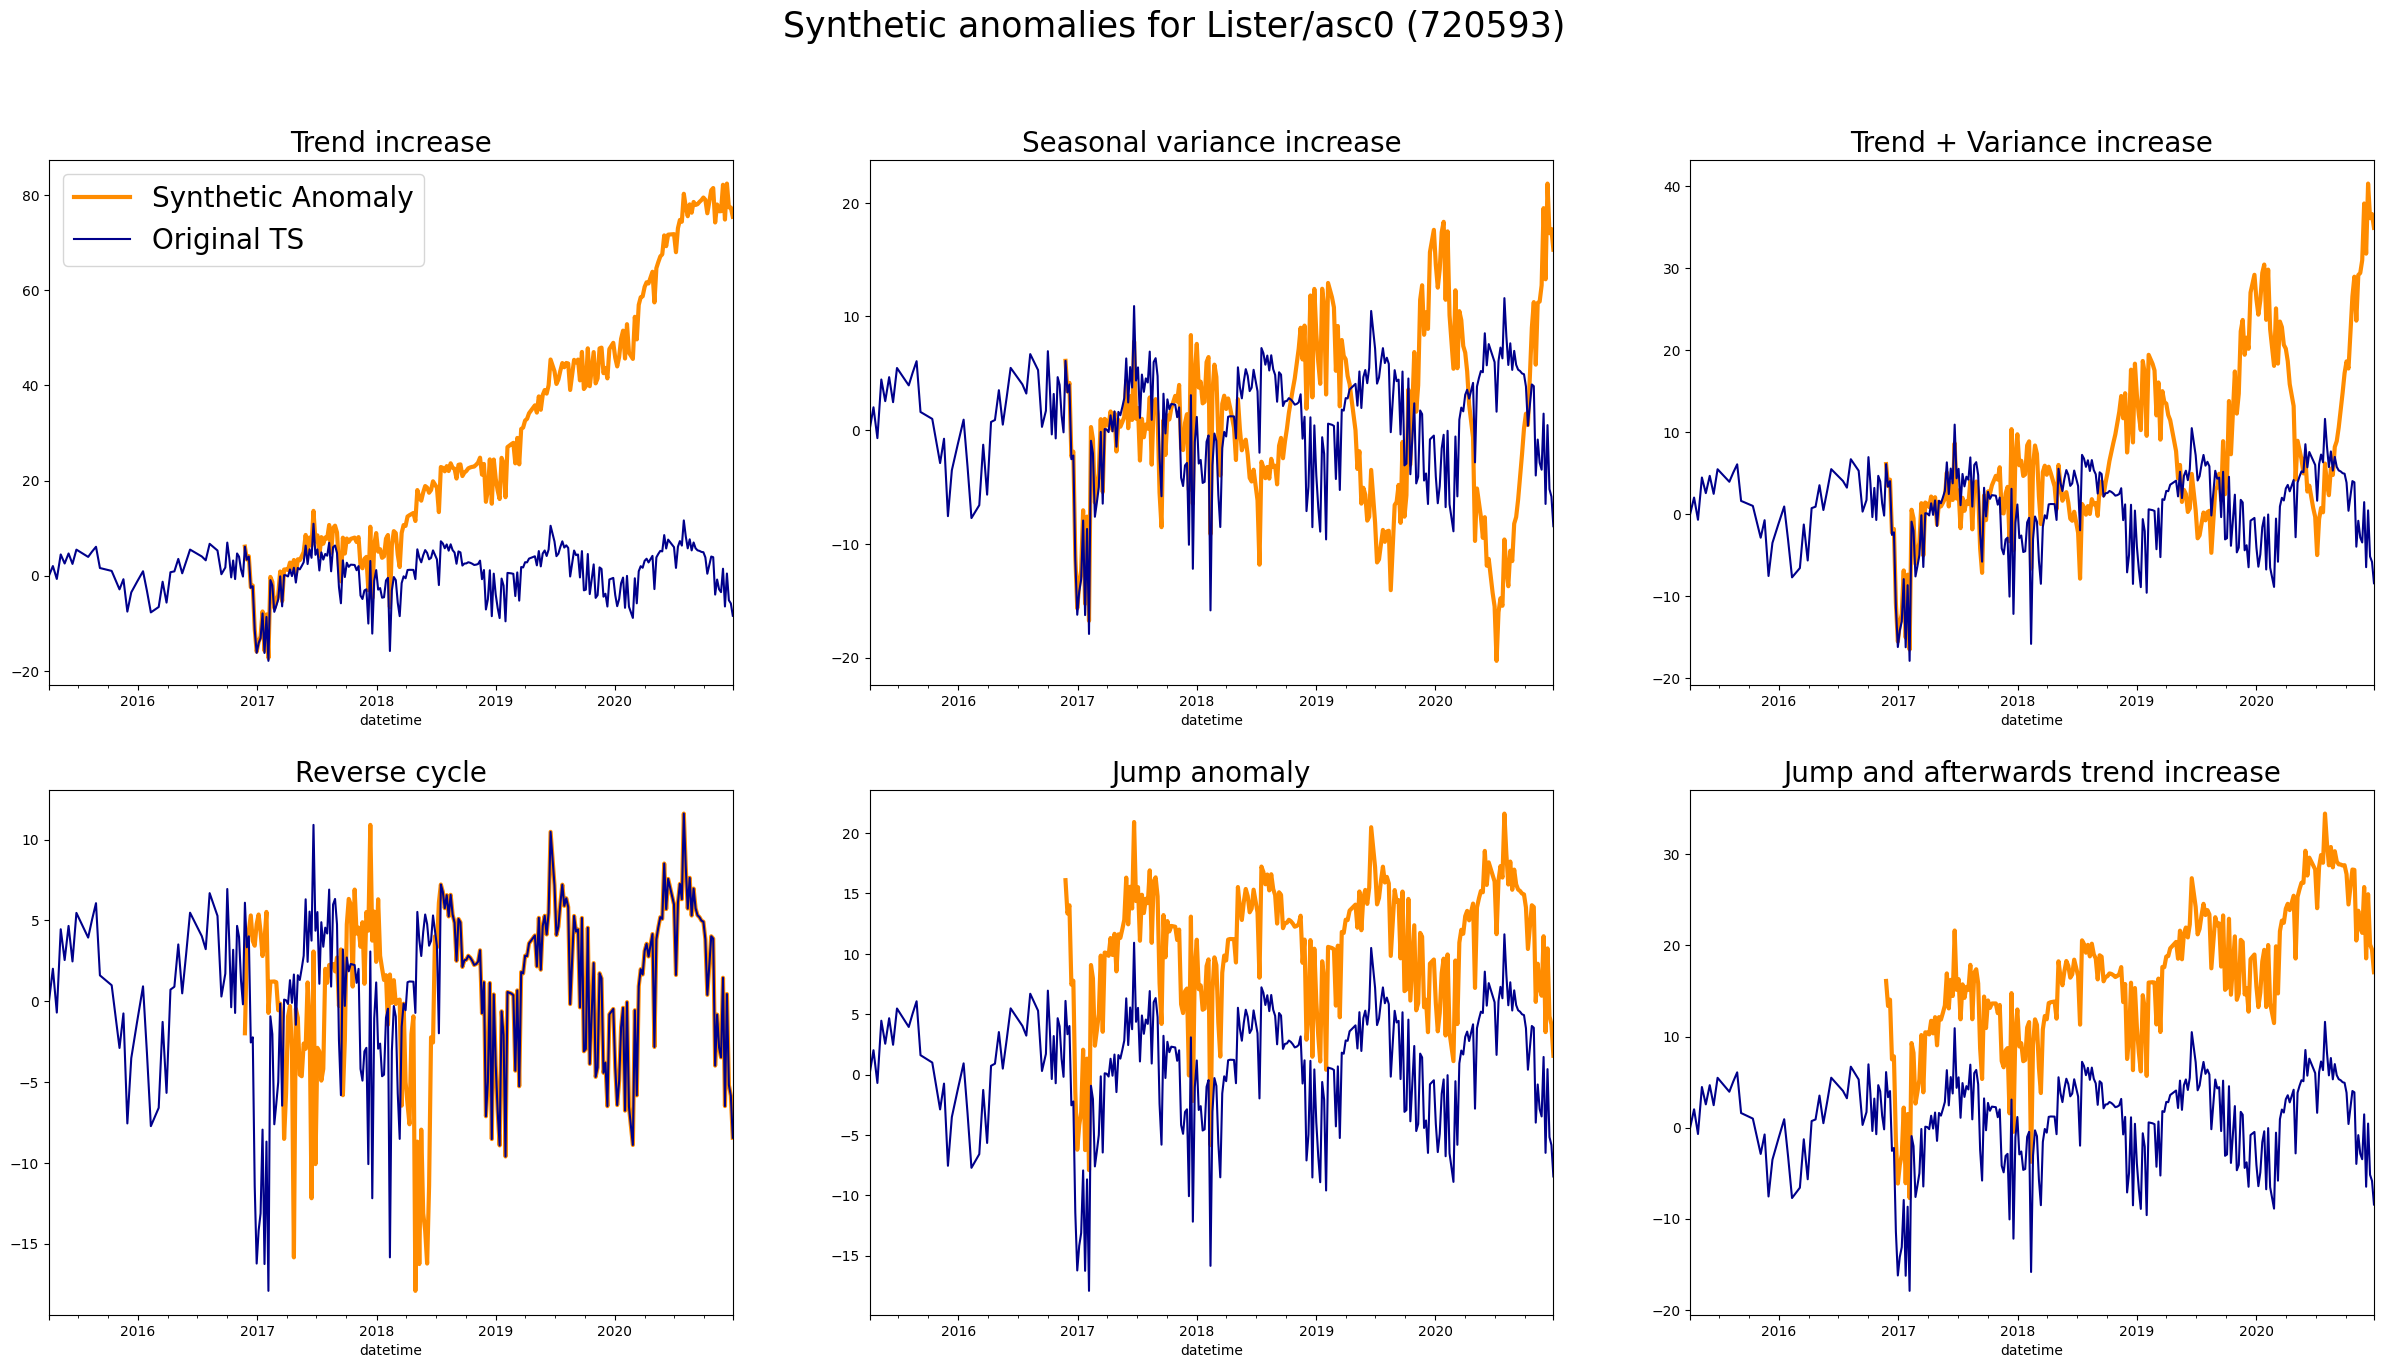

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(30, 15))
fig.suptitle("Synthetic anomalies for Lister/asc0 (720593)", fontsize=25)

variants = [a, b, c, d, e, f]
titles = [
    "Trend increase",
    "Seasonal variance increase",
    "Trend + Variance increase",
    "Reverse cycle",
    "Jump anomaly",
    "Jump and afterwards trend increase",
]


for n, ax in enumerate(axs.reshape(-1)):
    variants[n].columns = ["Synthetic Anomaly"]
    data.columns = ["Original TS"]
    variants[n][start:].plot(
        label="Synthetic Anomaly", color="darkorange", linewidth=3, ax=ax, legend=False
    )

    data.interpolate().plot(label="Original", color="darkblue", ax=ax, legend=False)
    ax.set_title(titles[n], fontsize=20)

axs[0, 0].legend(fontsize=20)